# Try to finally get this thing over with

In [14]:
import numpy as np
import cdv_utils
import matplotlib.pyplot as plt
import importlib
import glob
import re


plt.rcParams['text.usetex'] = True
plt.rcParams['pgf.texsystem'] = "pdflatex"
plt.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath,amsfonts,amssymb,cmbright,standalone}')
importlib.reload(cdv_utils)

<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [2]:
import pickle
from cdv_utils import (
    load_d, plot_lifetime_distributions_lines, diffusion_maps_matrix,
    compute_clusters_from_TO, classify_new_trajectory, calculate_escape_times,
    expected_escape_times_from_TO, add_scaled_top_axis, make_L3d, spy_col,
    solve_escape_from_Q, affinity_entry_sum, plot_loglog_slope_analysis)
fixed = np.array([
    [0.7285286,   0.15657308, -0.36810966, -0.32854071, -0.08004622, 0.34314342],
    [0.94484848, 0.10714876, -0.00858286, -0.71094887, -0.17206714, 0.03996197]
])

/tmp/ipykernel_435962/2556760277.py:33: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
/tmp/ipykernel_435962/2556760277.py:35: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,


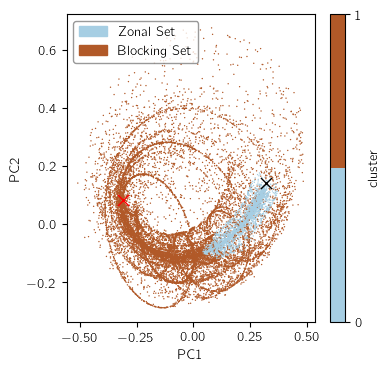

In [3]:
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
epsilon = 0.005
subsample_step = 10
n_eig = 12
n_clusters = 2
n_init = 10
eig_indices = [1, 2, 3, 4]   # zero-based eigenvector indices to use
random_state = 0
det_traj = load_d(
    "./cdv_model/data/dataOro20_sigma0p00000000.bin", 6, 200000)[::subsample_step, :]

# DMM, A = diffusion_maps_matrix(det_traj, epsilon)

L = make_L3d(det_traj, epsilon)

# --- compute clusters from TO ---
det_cluster_res = compute_clusters_from_TO(L.T,
                                           n_eig=n_eig,
                                           n_clusters=n_clusters,
                                           n_init=n_init,
                                           eig_indices=eig_indices,
                                           random_state=random_state)
pca = PCA(n_components=3)
PC_scores = pca.fit_transform(det_traj)
fixed_pcs = pca.transform(fixed)
labels = det_cluster_res["labels"].copy()
plt.figure(figsize=(4, 4))
cmap = plt.get_cmap("Paired", len(np.unique(labels)))
sc = plt.scatter(PC_scores[:-1, 0], PC_scores[:-1, 1],
                 c=labels, s=1, linewidth=0, cmap=cmap, label='Clusters',
                 rasterized=True)
plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")

handles = [
    mpatches.Patch(color=cmap(0), label=f'Zonal Set'),
    mpatches.Patch(color=cmap(1), label=f'Blocking Set')
]
plt.legend(
    handles=handles,
    loc='upper left',           # position inside the plot
    frameon=True,
    framealpha=0.8,             # slightly transparent background
    facecolor='white',
    edgecolor='gray'
)
plt.xlabel("PC1")
plt.ylabel("PC2")

cbar = plt.colorbar(sc, ticks=range(len(np.unique(det_cluster_res["labels"]))))
cbar.set_label('cluster')
cbar.set_ticklabels(range(len(np.unique(det_cluster_res["labels"]))))

In [4]:
# check above
blocking_idx = 0  # <- change this
blocking_mask = labels == blocking_idx

## Investigate dt dependence

38.608783783783785
[sparse-direct] used splu (n=19047, nnz=18899, density=5.209e-05).
38.608783783783785
entries: 148
blocking states: (19047,)
Processing sigma=0.0
Processing sigma=0.005
Processing sigma=0.01
Processing sigma=0.015
Processing sigma=0.02
Processing sigma=0.025
Processing sigma=0.03
Processing sigma=0.035
Processing sigma=0.04
Processing sigma=0.045
Processing sigma=0.05
38.89795918367347
[sparse-direct] used splu (n=11436, nnz=11289, density=8.632e-05).
38.89795918367347
entries: 147
blocking states: (11436,)
Processing epsilon = 0.000000
[sparse-direct] used splu (n=11436, nnz=11289, density=8.632e-05).
Processing epsilon = 0.000025
[sparse-direct] used splu (n=11436, nnz=5528921, density=0.04228).
Processing epsilon = 0.000100
[iterative] GMRES converged with ILU preconditioner (n=11436, nnz=13692929, density=0.1047).
Processing epsilon = 0.000225
[iterative] GMRES converged with ILU preconditioner (n=11436, nnz=23041947, density=0.1762).
Processing epsilon = 0.00040

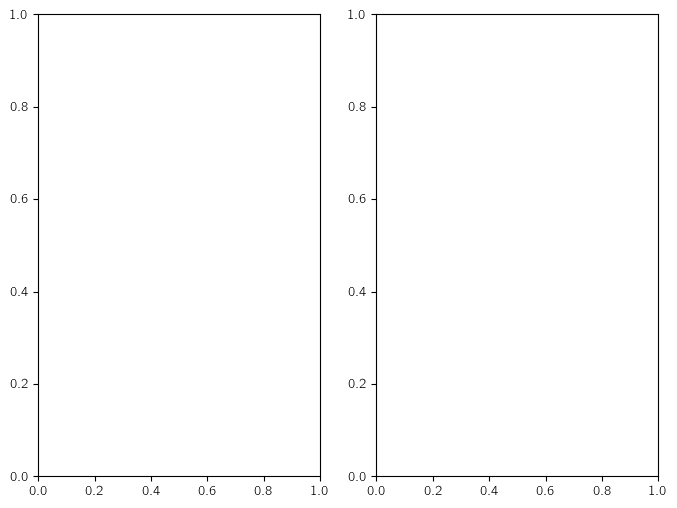

In [ ]:
# dt_dict = {}
# dt_dict_MonteCarlo = {}
dt_traj = 1e-2
for subsample_step_TO in [30, 50, 75, 100, 150, 200]:
    max_points = 2e6
    t_fin = int(subsample_step_TO * max_points)
    dt_eff_TO = dt_traj * subsample_step_TO
    det_traj_TO = load_d(
        "./cdv_model/datafine/dataOro20_sigma0p00000000.bin", 6, int(2e6))[:t_fin:subsample_step_TO, :]
    labels_TO = classify_new_trajectory(
        det_traj[:-1], labels, det_traj_TO, k=20, threshold=0.5
    )
    print(np.asarray(calculate_escape_times(
        labels_TO, dt=dt_eff_TO)[blocking_idx]).mean())
    entries = np.where(
        (labels_TO[:-1] != blocking_idx) & (labels_TO[1:] == blocking_idx))[0]+1
    indices_in_reduced = np.nonzero(labels_TO == blocking_idx)[0].searchsorted(
        entries[np.isin(entries, np.nonzero(labels_TO == blocking_idx)[0])])

    L = make_L3d(det_traj_TO, 0)
    Q = L[labels_TO[:-1] == blocking_idx][:,
                                          labels_TO[:-1] == blocking_idx].tocsr()
    t_escape = solve_escape_from_Q(Q) * dt_eff_TO
    print(t_escape[indices_in_reduced].mean())
    print("entries:", entries.shape[0])
    print("blocking states:", np.where(labels_TO == blocking_idx)[0].shape)

    if subsample_step_TO != 30:
        t_escape_dict = {}
        for sig in np.linspace(0, 0.05, 501)[::50]:
            eps = (2 * dt_eff_TO * sig**2)
            print(f"Processing epsilon = {eps:.6f}")

            L = make_L3d(det_traj_TO, eps)
            Q = L[labels_TO[:-1] == blocking_idx][:,
                                                  labels_TO[:-1] == blocking_idx].tocsr()
            t_escape = solve_escape_from_Q(Q)

            # Store
            t_escape_dict[eps] = t_escape[indices_in_reduced] * dt_eff_TO

        dt_dict[subsample_step_TO] = t_escape_dict
    escape_results = {}  # plain dict
    for fname in sorted(glob.glob("./cdv_model/datafine/dataOro20_sigma0p*.bin"))[::10]:
        # extract sigma string from filename (e.g. "0p050")
        match = re.search(r"sigma([0-9p]+)\.bin", fname)
        sigma_str = match.group(1).replace(
            "p", ".")   # e.g. "0p050" -> "0.050"
        sigma_val = float(sigma_str)
        print(f"Processing sigma={sigma_val}")

        sig_data = load_d(fname, 6, int(2e6))[::subsample_step_TO, :]

        # classify
        labels_new = classify_new_trajectory(
            det_traj[:-1], labels, sig_data, k=20, threshold=0.5
        )

        esc_dict = calculate_escape_times(labels_new, dt=dt_eff_TO)

        # insert into dict safely
        for regime, times in esc_dict.items():
            if regime not in escape_results:
                escape_results[regime] = {}
            if sigma_val not in escape_results[regime]:
                escape_results[regime][sigma_val] = []
            escape_results[regime][sigma_val].extend(times)
        dt_dict_MonteCarlo[subsample_step_TO] = escape_results

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_435962/3711235316.py:8: SyntaxWarning: invalid escape sequence '\D'
  label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
/tmp/ipykernel_435962/3711235316.py:13: SyntaxWarning: invalid escape sequence '\D'
  label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")


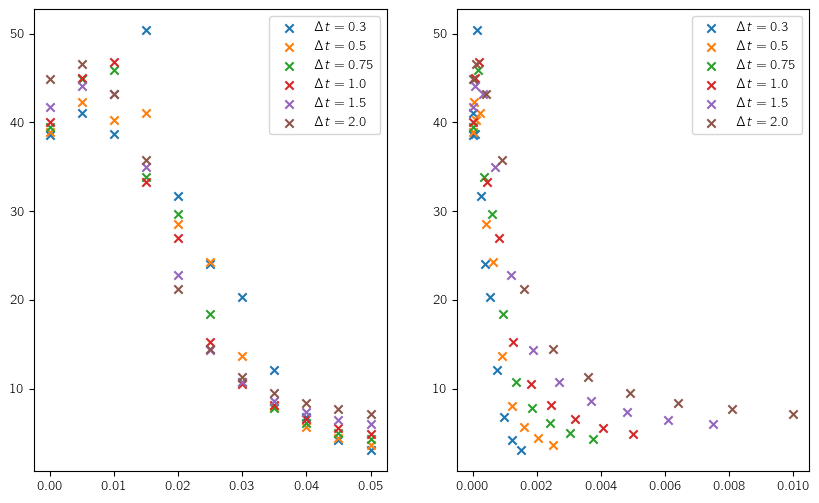

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
for subsample_step_TO in dt_dict.keys():
    t_escape_dict = dt_dict[subsample_step_TO]
    dt_eff_TO = dt_traj * subsample_step_TO
    axes[0].scatter(np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff_TO*2)),
                    np.array([t_escape_dict[k].mean()
                              for k in sorted(t_escape_dict.keys())]),
                    label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
    axes[0].legend()
    axes[1].scatter(np.array(sorted(t_escape_dict.keys())),
                    np.array([t_escape_dict[k].mean()
                              for k in sorted(t_escape_dict.keys())]),
                    label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
    axes[1].legend()

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_435962/373010513.py:8: SyntaxWarning: invalid escape sequence '\D'
  label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")


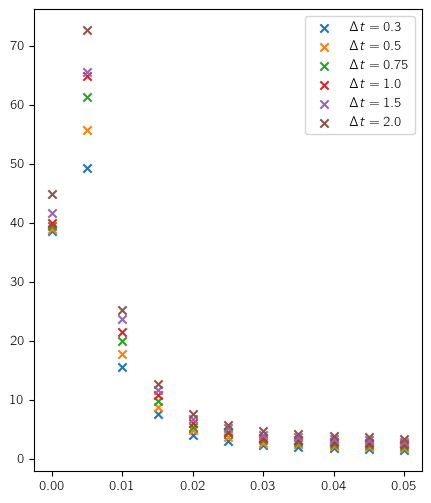

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 6))
for subsample_step_TO in dt_dict_MonteCarlo.keys():
    escape_results = dt_dict_MonteCarlo[subsample_step_TO]
    means = np.array([np.mean(v)
                      for k, v in sorted(escape_results[blocking_idx].items())])
    dt_eff_TO = dt_traj * subsample_step_TO
    ax.scatter(np.asarray(sorted(escape_results[blocking_idx].keys()), dtype=float), means,
               label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
    ax.legend()